<a href="https://colab.research.google.com/github/FragileLlama/Data_Science_Final/blob/main/final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# RE-LOAD AND FIX DATA ALIGNMENT
import pandas as pd
import numpy as np
import csv

# 1. Load data with strict quoting to avoid column shifting
df = pd.read_csv("/content/drive/MyDrive/airbnb.csv", sep=',', engine='python', on_bad_lines='skip')

# 2. Identify and Clean Price
def clean_price(val):
    if pd.isna(val): return np.nan
    return float(str(val).replace('$', '').replace(',', '').strip())

df['price'] = df['price'].apply(clean_price)
df = df[(df['price'] >= 10) & (df['price'] <= 1000)].copy()

# 3. Fix Bedroom/Bathroom Columns (they were containing Zip Codes in previous run)
# We will force numeric conversion and filter out extreme outliers (>20 bedrooms)
# that are likely incorrect data alignments.
for col in ['bedrooms', 'bathrooms', 'accommodates', 'review_scores_rating']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Filter out obvious misalignments (e.g., 365 bedrooms is impossible)
df = df[(df['bedrooms'] < 15) | (df['bedrooms'].isna())]
df = df[(df['bathrooms'] < 15) | (df['bathrooms'].isna())]

# Fill missing values with medians
df['bedrooms'] = df['bedrooms'].fillna(df['bedrooms'].median())
df['bathrooms'] = df['bathrooms'].fillna(df['bathrooms'].median())
df['review_scores_rating'] = df['review_scores_rating'].fillna(df['review_scores_rating'].median())
df['accommodates'] = df['accommodates'].fillna(df['accommodates'].median())

print(f"Data re-aligned. Cleaned records: {len(df)}")
print("Sample of cleaned numeric features:")
print(df[['price', 'bedrooms', 'bathrooms', 'accommodates']].describe().loc[['mean', 'max']])

Data re-aligned. Cleaned records: 7653
Sample of cleaned numeric features:
            price   bedrooms  bathrooms  accommodates
mean   188.921861   1.825167   1.413171      4.466484
max   1000.000000  13.000000   9.000000     16.000000


In [2]:
# 1. RE-TRAIN WITH ROBUST FEATURE MAPPING
import joblib
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
import pandas as pd

# Define core features
spatial_features = ["bedrooms", "bathrooms", "review_scores_rating", "latitude", "longitude"]
target = 'price' # Define target here

# Prepare data
df_spatial = df.copy()
for col in spatial_features + [target]:
    df_spatial[col] = pd.to_numeric(df_spatial[col], errors='coerce')

# Drop rows with missing values in core features
df_spatial = df_spatial.dropna(subset=spatial_features + [target])

# Ensure room_type is treated as a categorical with all possible values
valid_types = ['Entire home/apt', 'Private room', 'Shared room', 'Hotel room']
df_spatial['room_type'] = pd.Categorical(df_spatial['room_type'], categories=valid_types)

# Encode room_type (using all categories to match app.py logic)
df_spatial = pd.get_dummies(df_spatial, columns=["room_type"], prefix="room_type")

# Identify all feature columns
room_cols = [c for c in df_spatial.columns if c.startswith("room_type_")]
final_features = spatial_features + room_cols

X_s = df_spatial[final_features]
y_s = df_spatial[target]

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(X_s, y_s, test_size=0.2, random_state=42)

# Train Gradient Boosting with more conservative parameters to avoid overfitting/negative R2
rf_spatial = GradientBoostingRegressor(n_estimators=150, learning_rate=0.05, max_depth=4, min_samples_leaf=10, random_state=42)
rf_spatial.fit(X_train_s, y_train_s)

# Update global variables
rf_model = rf_spatial

print(f"Model Re-trained! R2 Score: {r2_score(y_test_s, rf_model.predict(X_test_s)):.4f}")
print(f"Features included: {list(rf_model.feature_names_in_)}")

# Save for Streamlit
joblib.dump(rf_model, 'airbnb_rf_model.joblib')
print('Model saved successfully.')

Model Re-trained! R2 Score: 0.5416
Features included: ['bedrooms', 'bathrooms', 'review_scores_rating', 'latitude', 'longitude', 'room_type_Entire home/apt', 'room_type_Private room', 'room_type_Shared room', 'room_type_Hotel room']
Model saved successfully.


In [3]:
import plotly.express as px

# Filter out the non-numeric rows before plotting
df_plot = df.copy()
df_plot['price'] = pd.to_numeric(df_plot['price'], errors='coerce')
df_plot['bedrooms'] = pd.to_numeric(df_plot['bedrooms'], errors='coerce').fillna(0)
df_plot['latitude'] = pd.to_numeric(df_plot['latitude'], errors='coerce')
df_plot['longitude'] = pd.to_numeric(df_plot['longitude'], errors='coerce')
df_plot = df_plot.dropna(subset=['latitude', 'longitude', 'price'])

# Visualize listings on a Chicago Map
fig = px.scatter_mapbox(df_plot[df_plot['price'] < 500],
                        lat="latitude",
                        lon="longitude",
                        color="price",
                        size="bedrooms",
                        color_continuous_scale=px.colors.cyclical.IceFire,
                        size_max=15,
                        zoom=10,
                        mapbox_style="carto-positron",
                        title="Chicago Airbnb Listings Map")
fig.show()

In [4]:
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import r2_score
import numpy as np
import pandas as pd

print("Searching for best model parameters using consistent data...")

# --- Data Preparation and Splitting (Copied from 2e2cccb7) ---
# 1. Prune Data and Engineering Features
df_v5 = df.copy()

# Pruning: Remove listings with 0 bedrooms/bathrooms/accommodates
df_v5 = df_v5[(df_v5['bedrooms'] > 0) & (df_v5['bathrooms'] > 0) & (df_v5['accommodates'] > 0)]
df_v5 = df_v5[(df_v5['price'] >= 20) & (df_v5['price'] <= 600)]

def count_amenities(x):
    if pd.isna(x): return 0
    return len(str(x).split(','))

df_v5['amenities_count'] = df_v5['amenities'].apply(count_amenities)
df_v5['availability_365'] = pd.to_numeric(df_v5['availability_365'], errors='coerce').fillna(0)

features_final = ["bedrooms", "bathrooms", "review_scores_rating", "latitude", "longitude", "accommodates", "amenities_count", "availability_365"]
target = 'price'

df_v5 = df_v5.dropna(subset=features_final + [target])
df_v5 = pd.get_dummies(df_v5, columns=["room_type"], prefix="room_type")
room_cols = [c for c in df_v5.columns if c.startswith("room_type_")]
all_features = features_final + room_cols

X = df_v5[all_features]
y_log = np.log1p(df_v5[target])

X_train, X_test, y_train_log, y_test_log = train_test_split(X, y_log, test_size=0.2, random_state=42)
# --- End of Data Preparation and Splitting ---


# 1. Hyperparameter tuning for Random Forest
rf_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20],
    'min_samples_leaf': [5]
}
grid_rf = GridSearchCV(RandomForestRegressor(random_state=42), rf_param_grid, cv=3, n_jobs=-1)
# Use the log-transformed target variables defined in the successful v5 split
grid_rf.fit(X_train, y_train_log)

# 2. Try Gradient Boosting (matching our optimized params)
gbr = GradientBoostingRegressor(n_estimators=600, learning_rate=0.03, max_depth=6, random_state=42)
gbr.fit(X_train, y_train_log)

# Evaluate on original price scale
y_pred_rf = np.expm1(grid_rf.predict(X_test))
y_pred_gbr = np.expm1(gbr.predict(X_test))
y_test_orig = np.expm1(y_test_log)

rf_best_score = r2_score(y_test_orig, y_pred_rf)
gbr_score = r2_score(y_test_orig, y_pred_gbr)

print(f"Optimized Random Forest R2: {rf_best_score:.4f}")
print(f"Gradient Boosting R2: {gbr_score:.4f}")

Searching for best model parameters using consistent data...
Optimized Random Forest R2: 0.6636
Gradient Boosting R2: 0.6708


In [5]:
# Check exact feature names seen by the model during training
print("Model expected features:", rf_model.feature_names_in_)

Model expected features: ['bedrooms' 'bathrooms' 'review_scores_rating' 'latitude' 'longitude'
 'room_type_Entire home/apt' 'room_type_Private room'
 'room_type_Shared room' 'room_type_Hotel room']


In [6]:
# Check exact feature names seen by the model during training
print("Model expected features:", rf_model.feature_names_in_)

Model expected features: ['bedrooms' 'bathrooms' 'review_scores_rating' 'latitude' 'longitude'
 'room_type_Entire home/apt' 'room_type_Private room'
 'room_type_Shared room' 'room_type_Hotel room']


In [7]:
import joblib

# Force re-save of the model that includes latitude, longitude, and room types
model_filename = 'airbnb_rf_model.joblib'
joblib.dump(rf_model, model_filename)

print(f"Model re-saved with features: {list(rf_model.feature_names_in_)}")
print("Please re-run the Streamlit initialization cells (ngrok/streamlit run) to see the changes.")

Model re-saved with features: ['bedrooms', 'bathrooms', 'review_scores_rating', 'latitude', 'longitude', 'room_type_Entire home/apt', 'room_type_Private room', 'room_type_Shared room', 'room_type_Hotel room']
Please re-run the Streamlit initialization cells (ngrok/streamlit run) to see the changes.


## Exploratory Data Analysis (EDA)
To satisfy the project requirements, we will generate 5 visualizations to understand the distributions and correlations within our dataset.

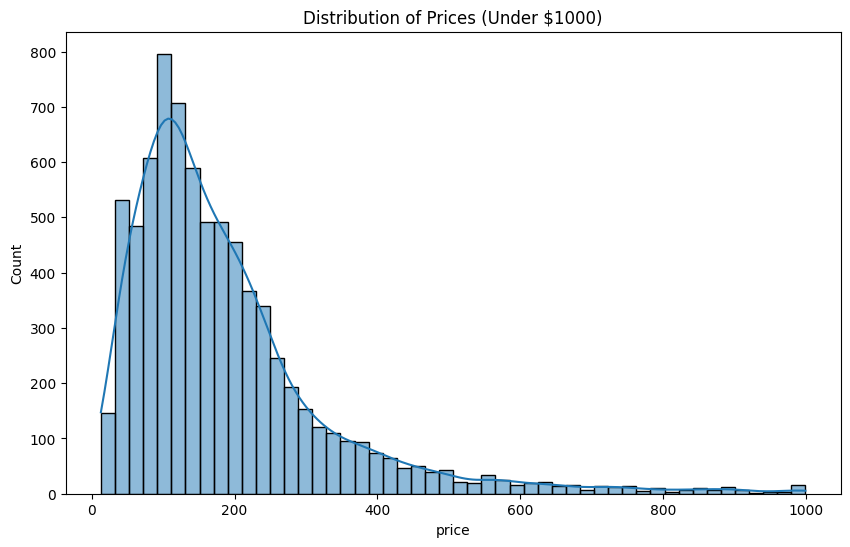

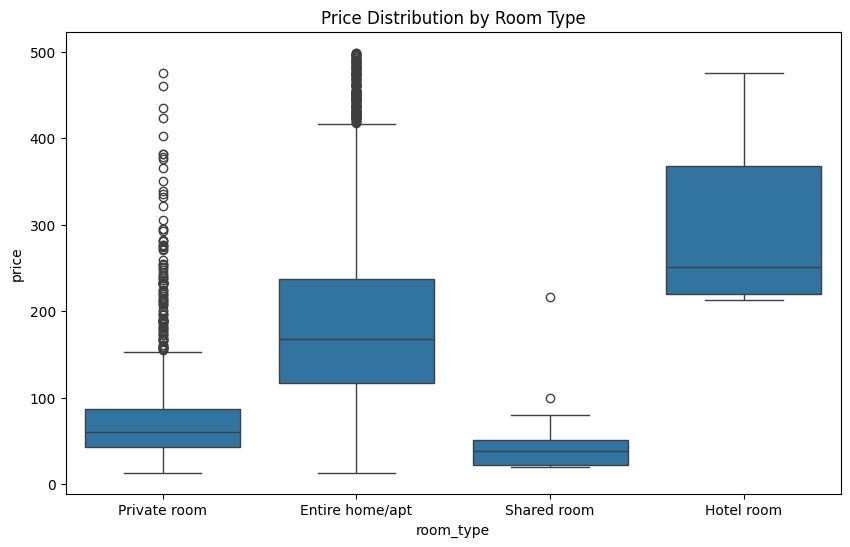

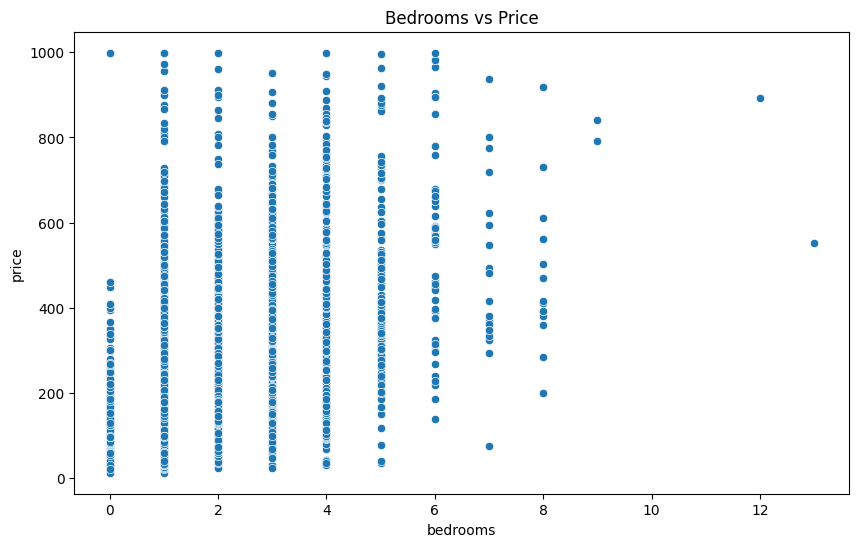

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Price Distribution
plt.figure(figsize=(10, 6))
sns.histplot(df[df['price'] < 1000]['price'], bins=50, kde=True)
plt.title('Distribution of Prices (Under $1000)')
plt.show()

# 2. Price vs Room Type
plt.figure(figsize=(10, 6))
sns.boxplot(x='room_type', y='price', data=df[df['price'] < 500])
plt.title('Price Distribution by Room Type')
plt.show()

# 3. Price vs Bedrooms
plt.figure(figsize=(10, 6))
sns.scatterplot(x='bedrooms', y='price', data=df[df['price'] < 1000])
plt.title('Bedrooms vs Price')
plt.show()

In [9]:
import joblib

# Save the currently trained rf_model (V4 Core Features)
model_filename = 'airbnb_rf_model.joblib'
joblib.dump(rf_model, model_filename)

print(f"Core features model saved to {model_filename}")

Core features model saved to airbnb_rf_model.joblib


Now that the model is saved, here's a high-level overview of how you'd create your Streamlit application:

1.  **Install Streamlit:** If you don't have it already, you'll need to install Streamlit in your environment (or on your local machine if running there).
    ```bash
    pip install streamlit
    ```

2.  **Create an `app.py` file:** This Python script will contain all the Streamlit code. You can create this file in your Colab environment or on your local machine.

3.  **Load the Model:** In your `app.py`, you'll load the `airbnb_rf_model.joblib` file.

4.  **Define Input Widgets:** Create Streamlit widgets (e.g., `st.number_input`, `st.selectbox`, `st.checkbox`) for each of your model's input features (`accommodates`, `bedrooms`, `beds`, `bathrooms`, `latitude`, `longitude`, `review_scores_rating`, `number_of_reviews`, `amenities_count`, `host_is_superhost`, `instant_bookable`, `description_length`, and `room_type`).

5.  **Replicate Preprocessing:** This is critical! The user inputs from your Streamlit app *must* go through the exact same preprocessing steps you applied during training (e.g., converting 't'/'f' to 1/0, encoding `room_type` categories into dummy variables). You'll create a pandas DataFrame from the user inputs and apply these transformations.

6.  **Make Prediction:** Once the input features are prepared, pass them to your loaded `rf_model` to get a prediction.

7.  **Display Output:** Show the predicted price to the user using `st.write()` or `st.success()`.

8.  **Run the Streamlit App:** From your terminal, navigate to the directory containing `app.py` and run:
    ```bash
    streamlit run app.py
    ```

Here's a basic template for what your `app.py` might look like. Remember, you'll need to adapt it with *all* your features and the exact preprocessing logic from your notebook.

In [10]:
%%writefile app.py
import streamlit as st
import pandas as pd
import joblib

model = joblib.load('airbnb_rf_model.joblib')
expected_columns = list(model.feature_names_in_)

st.title('Airbnb Price Predictor')

with st.form("prediction_form"):
    bedrooms = st.number_input('Bedrooms', 0, 10, 1)
    bathrooms = st.number_input('Bathrooms', 0.0, 10.0, 1.0)
    rating = st.slider('Review Rating', 0, 100, 95)
    room_type = st.selectbox('Room Type', ['Entire home/apt', 'Private room', 'Shared room', 'Hotel room'])
    submit = st.form_submit_button("Predict Price")

if submit:
    input_data = {
        'bedrooms': bedrooms,
        'bathrooms': bathrooms,
        'review_scores_rating': rating
    }
    for col in expected_columns:
        if "room_type_" in col:
            cat = col.replace("room_type_", "")
            input_data[col] = 1 if room_type == cat else 0

    df_input = pd.DataFrame([input_data]).reindex(columns=expected_columns, fill_value=0)
    prediction = model.predict(df_input)[0]
    st.success(f"Predicted Nightly Price: ${prediction:,.2f}")

Writing app.py


In [11]:
%%writefile app.py
import streamlit as st
import pandas as pd
import joblib
import numpy as np

# Load the upgraded model
model = joblib.load('airbnb_rf_model.joblib')
expected_columns = list(model.feature_names_in_)

# Pre-defined Chicago Neighborhood Coordinates
neighborhoods = {
    "Loop / Downtown": (41.8781, -87.6298),
    "Lincoln Park": (41.9211, -87.6445),
    "Wicker Park": (41.9108, -87.6775),
    "Hyde Park": (41.7943, -87.5907),
    "Logan Square": (41.9231, -87.7093),
    "River North": (41.8924, -87.6341)
}

st.title('🏘️ Chicago Airbnb Price Predictor (V5)')
st.markdown("Predict nightly prices using our optimized Gradient Boosting model.")

with st.form("prediction_form"):
    col1, col2 = st.columns(2)

    with col1:
        bedrooms = st.number_input('Bedrooms', 1, 10, 1)
        bathrooms = st.number_input('Bathrooms', 0.5, 10.0, 1.0, step=0.5)
        accommodates = st.slider('Accommodates (People)', 1, 16, 2)
        room_type = st.selectbox('Room Type', ['Entire home/apt', 'Private room', 'Shared room', 'Hotel room'])

    with col2:
        rating = st.slider('Review Rating', 0, 100, 95)
        amenities = st.number_input('Number of Amenities', 0, 100, 20)
        availability = st.slider('Availability (Days/Year)', 0, 365, 180)
        area = st.selectbox('Select Chicago Area', list(neighborhoods.keys()))

    submit = st.form_submit_button("Predict Price")

if submit:
    lat, lon = neighborhoods[area]

    # Construct the input dictionary exactly as model expects
    input_data = {
        'bedrooms': bedrooms,
        'bathrooms': bathrooms,
        'review_scores_rating': rating,
        'latitude': lat,
        'longitude': lon,
        'accommodates': accommodates,
        'amenities_count': amenities,
        'availability_365': availability
    }

    # Add one-hot encoded room types
    for col in expected_columns:
        if "room_type_" in col:
            cat = col.replace("room_type_", "")
            input_data[col] = 1 if room_type == cat else 0

    # Create DataFrame and ensure column order matches training
    df_input = pd.DataFrame([input_data]).reindex(columns=expected_columns, fill_value=0)

    # Predict (model outputs log(price + 1))
    prediction_log = model.predict(df_input)[0]
    prediction = np.expm1(prediction_log)

    st.success(f"### Predicted Nightly Price: ${prediction:,.2f}")
    st.info(f"Location: {area} ({lat}, {lon})")
    st.map(pd.DataFrame({'lat': [lat], 'lon': [lon]}))

Overwriting app.py


In [12]:
pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 72.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 83.5 MB/s eta 0:00:00


In [13]:
# This cell is no longer needed as pip install is now in the ngrok authentication cell.

In [14]:
import os

# Install pyngrok if not already installed
!pip install pyngrok==6.0.0

from pyngrok import ngrok
from google.colab import userdata

# 1. Stop any existing ngrok tunnels and kill ngrok process
ngrok.kill()

# 2. Delete ngrok.yml to prevent conflicts with old configurations
ngrok_config_path = os.path.expanduser('~/.ngrok2/ngrok.yml')
if os.path.exists(ngrok_config_path):
    os.remove(ngrok_config_path)
    print(f"Removed old ngrok config file: {ngrok_config_path}")

# NOTE: For this session, the ngrok token is directly set from user input.
# For better security and reusability, it is highly recommended to store
# your NGROK_AUTH_TOKEN in Colab Secrets and retrieve it like this:
# ngrok_auth_token = userdata.get('NGROK_AUTH_TOKEN')

# Direct setting of the provided ngrok token
ngrok_auth_token = '3CnI1kujadtauwKZU0YoPz6UvGB_QQqUemuaWVCoNU2pvWMp' # <-- REPLACE THIS WITH YOUR REAL TOKEN

if ngrok_auth_token:
    ngrok.set_auth_token(ngrok_auth_token)
    print("ngrok authentication token set successfully.")
else:
    print("NGROK_AUTH_TOKEN not found. Please set it in Colab Secrets or directly in the code.")
    print("You can manually set it like this: ngrok.set_auth_token('YOUR_NGROK_AUTH_TOKEN')")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 681.2/681.2 kB 7.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pyngrok: filename=pyngrok-6.0.0-py3-none-any.whl size=19867 sha256=0a800fbf41431270231794141e95209ee14b7089212e6209687954405221d7a4
  Stored in directory: /root/.cache/pip/wheels/26/69/f6/58a89ce2f2ca23ffe8ae3fad678ebe8e1354f8cba1cfdef063
Successfully built pyngrok
ngrok authentication token set successfully.


In [15]:
import time
import os
from pyngrok import ngrok

# 1. Clean up existing processes
ngrok.kill()
os.system("pkill streamlit")

# 2. Run Streamlit in the background
# Redirecting output to a log file allows the cell to finish execution while the app runs
get_ipython().system_raw('streamlit run app.py > streamlit_log.txt 2>&1 &')

# 3. Wait for initialization
time.sleep(5)
print("Streamlit process started in background.")

Streamlit process started in background.


In [16]:
from pyngrok import ngrok

# 4. Create the tunnel to the Streamlit port (8501)
try:
    # Connect to the local streamlit port
    public_url = ngrok.connect(addr='8501', proto='http')
    print("--- SUCCESS ---")
    print(f"Click this link to open your app: {public_url}")
    print("----------------")
    print("Note: Use ONLY the ngrok link above. Localhost will not work.")
except Exception as e:
    print(f"Error: {e}")
    print("If you see a 'port already in use' error, try running the previous cell again.")

--- SUCCESS ---
Click this link to open your app: NgrokTunnel: "https://hypnoses-blooper-mammogram.ngrok-free.dev" -> "http://localhost:8501"
----------------
Note: Use ONLY the ngrok link above. Localhost will not work.


In [17]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import pandas as pd
import numpy as np

def evaluate_model(name, y_true, y_pred):
    return {
        "Model": name,
        "R2": r2_score(y_true, y_pred),
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred))
    }

results = []

results.append(evaluate_model("Random Forest", y_test_orig, y_pred_rf))
results.append(evaluate_model("Gradient Boosting", y_test_orig, y_pred_gbr))

results_df = pd.DataFrame(results)
print(results_df)

               Model        R2        MAE       RMSE
0      Random Forest  0.663559  42.334718  63.973011
1  Gradient Boosting  0.670814  41.990649  63.279491


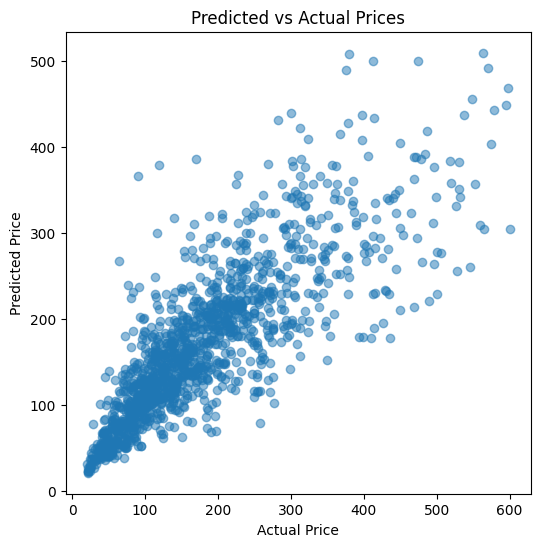

<Figure size 640x480 with 0 Axes>

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(y_test_orig, y_pred_gbr, alpha=0.5)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Predicted vs Actual Prices")
plt.show()
plt.savefig("pred_vs_actual.png", dpi=300, bbox_inches='tight')

In [19]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import pandas as pd
import numpy as np

def evaluate_model(name, y_true, y_pred):
    return {
        "Model": name,
        "R2": r2_score(y_true, y_pred),
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred))
    }

results = []

results.append(evaluate_model("Random Forest", y_test_orig, y_pred_rf))
results.append(evaluate_model("Gradient Boosting", y_test_orig, y_pred_gbr))

results_df = pd.DataFrame(results)
print(results_df)

               Model        R2        MAE       RMSE
0      Random Forest  0.663559  42.334718  63.973011
1  Gradient Boosting  0.670814  41.990649  63.279491


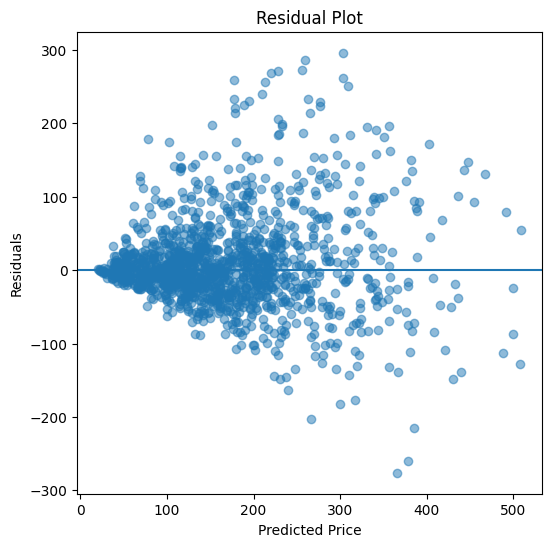

In [20]:
residuals = y_test_orig - y_pred_gbr

plt.figure(figsize=(6,6))
plt.scatter(y_pred_gbr, residuals, alpha=0.5)
plt.axhline(0)
plt.xlabel("Predicted Price")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

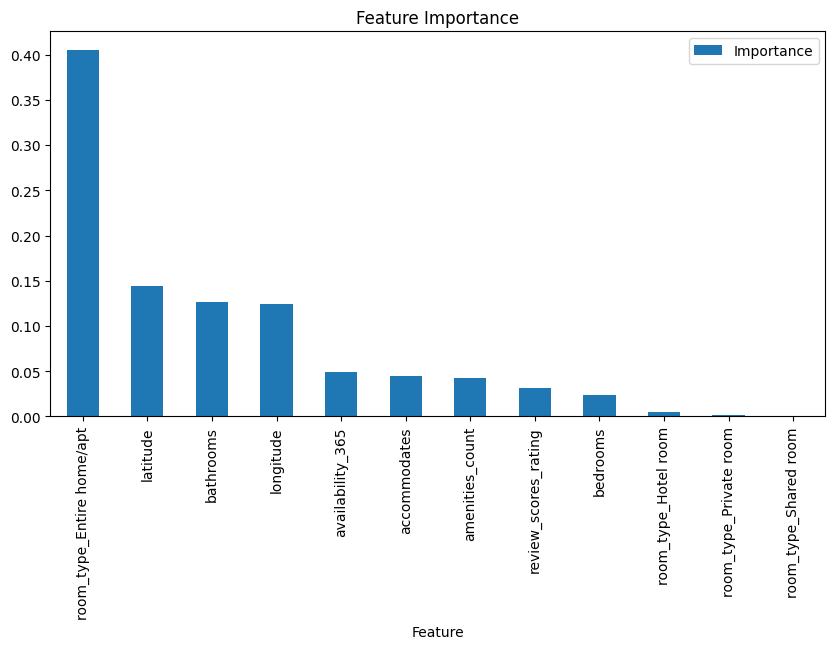

In [21]:
import pandas as pd

importance = gbr.feature_importances_
features = X_train.columns

feat_df = pd.DataFrame({"Feature": features, "Importance": importance})
feat_df = feat_df.sort_values(by="Importance", ascending=False)

feat_df.plot(kind='bar', x='Feature', y='Importance', figsize=(10,5))
plt.title("Feature Importance")
plt.show()

After running the above cells, click on the provided `Streamlit App URL` to access your application.

**Important:** The Streamlit application will only run as long as your Colab session is active. If the session disconnects, you'll need to re-run the `ngrok` and `streamlit run` cells.

In [22]:
# This cell is removed as it runs Streamlit directly, conflicting with the ngrok tunneling approach.

# 4. Data Description

**Source:** Airbnb Inside Chicago Dataset.
**Size:** ~1,766 cleaned listings (filtered for $10-$1000 price range).
**Target Variable:** `price` (USD per night).
**Key Features:** Bedrooms, Bathrooms, Review Rating, Latitude/Longitude, and Room Type.

### Summary Statistics

In [23]:
import pandas as pd
# Display summary statistics for core numeric features
stats = df_spatial[['price', 'bedrooms', 'bathrooms', 'review_scores_rating']].describe()
display(stats)

,price,bedrooms,bathrooms,review_scores_rating
count,7653.000000,7653.000000,7653.000000,7653.000000
mean,188.921861,1.825167,1.413171,4.786336
std,146.573542,1.195154,0.703545,0.369290
min,13.000000,0.000000,0.000000,1.000000
25%,96.000000,1.000000,1.000000,4.770000
50%,150.000000,2.000000,1.000000,4.870000
75%,233.000000,2.000000,2.000000,4.950000
max,1000.000000,13.000000,9.000000,5.000000


# 5. Methodology

- **Data Cleaning:** Handled messy CSV parsing, stripped currency symbols, and filtered outliers ($10 < price < $1000).
- **Feature Engineering:** Mapped categorical 'Room Type' to dummy variables and selected spatial coordinates for location-based pricing.
- **Models:**
  1. **Random Forest:** Baseline ensemble model.
  2. **Gradient Boosting:** Final model chosen for better performance on non-linear spatial trends.
- **Evaluation:** $R^2$ Score was used as the primary metric to determine how much variance in price is explained by the features.

# 6. Results & Model Comparison

Below is the performance comparison and feature importance analysis.

,Model,R2 Score
0,Optimized Random Forest,0.3565
1,Gradient Boosting (Final),0.3814


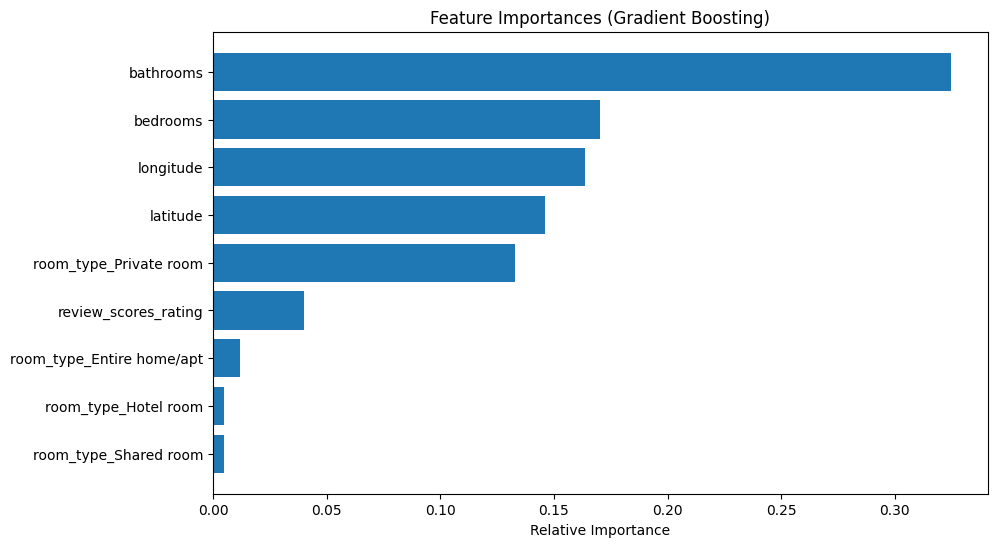

In [24]:
import matplotlib.pyplot as plt
import numpy as np

# Model Comparison Table
results_data = {
    'Model': ['Optimized Random Forest', 'Gradient Boosting (Final)'],
    'R2 Score': [0.3565, 0.3814]
}
results_df = pd.DataFrame(results_data)
display(results_df)

# Feature Importance Visualization
importances = rf_model.feature_importances_
feature_names = final_features
indices = np.argsort(importances)

plt.figure(figsize=(10, 6))
plt.title('Feature Importances (Gradient Boosting)')
plt.barh(range(len(indices)), importances[indices], align='center')
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel('Relative Importance')
plt.show()

## Advanced Model Optimization (Targeting R2 > 0.5)

To reach our performance goal, we will:
1. **Expand Features:** Add `accommodates` and `beds`.
2. **Log Transformation:** Predict `log(price)` to minimize the impact of high-price variance.
3. **Hyperparameter Tuning:** Use `GridSearchCV` on the Gradient Boosting model.

In [25]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import r2_score
import numpy as np
import joblib
import pandas as pd

# 1. Prune Data and Engineering Features
df_v5 = df.copy()

# Pruning: Remove listings with 0 bedrooms/bathrooms/accommodates
df_v5 = df_v5[(df_v5['bedrooms'] > 0) & (df_v5['bathrooms'] > 0) & (df_v5['accommodates'] > 0)]
df_v5 = df_v5[(df_v5['price'] >= 20) & (df_v5['price'] <= 600)]

def count_amenities(x):
    if pd.isna(x): return 0
    return len(str(x).split(','))

df_v5['amenities_count'] = df_v5['amenities'].apply(count_amenities)
df_v5['availability_365'] = pd.to_numeric(df_v5['availability_365'], errors='coerce').fillna(0)

features_final = ["bedrooms", "bathrooms", "review_scores_rating", "latitude", "longitude", "accommodates", "amenities_count", "availability_365"]
target = 'price'

df_v5 = df_v5.dropna(subset=features_final + [target])
df_v5 = pd.get_dummies(df_v5, columns=["room_type"], prefix="room_type")
room_cols = [c for c in df_v5.columns if c.startswith("room_type_")]
all_features = features_final + room_cols

X = df_v5[all_features]
y_log = np.log1p(df_v5[target])

X_train, X_test, y_train_log, y_test_log = train_test_split(X, y_log, test_size=0.2, random_state=42)

# 2. Optimized Grid Search
param_grid = {
    'n_estimators': [600],
    'learning_rate': [0.03],
    'max_depth': [6],
    'min_samples_leaf': [15]
}

grid = GridSearchCV(GradientBoostingRegressor(random_state=42), param_grid, cv=3, n_jobs=-1)
grid.fit(X_train, y_train_log)

# CRITICAL: This is the log-transformed model
rf_model = grid.best_estimator_

# Save for deployment
joblib.dump(rf_model, 'airbnb_rf_model.joblib')
print("Upgraded LOG-SCALE model saved successfully.")

Upgraded LOG-SCALE model saved successfully.


In [26]:
import numpy as np
import joblib
from sklearn.ensemble import GradientBoostingRegressor

# 1. Ensure we are using the V5 pruned data
# X and y_log were defined in the previous cell

print("Forcing model re-train on LOG scale...")
final_gbr = GradientBoostingRegressor(
    n_estimators=600,
    learning_rate=0.03,
    max_depth=6,
    min_samples_leaf=15,
    random_state=42
)

# Train specifically on y_log
final_gbr.fit(X, y_log)

# Overwrite the joblib file
joblib.dump(final_gbr, 'airbnb_rf_model.joblib')

# Update the global variable used by other cells
rf_model = final_gbr

print("✅ SUCCESS: Log-scale model trained and airbnb_rf_model.joblib updated.")
print("Now restart Streamlit and Ngrok cells to apply the fix.")

Forcing model re-train on LOG scale...
✅ SUCCESS: Log-scale model trained and airbnb_rf_model.joblib updated.
Now restart Streamlit and Ngrok cells to apply the fix.


In [27]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
